# Milestone 3 - Modelação e Avaliação (Objetivo 1)

Neste notebook é realizada a fase de modelação do dataset IBM HR Analytics Employee Attrition & Performance, com foco no desenvolvimento de modelos de classificação supervisionada capazes de prever o abandono de colaboradores (Attrition).

Este trabalho enquadra-se nas fases de Modelling e Evaluation da metodologia CRISP-DM, dando continuidade à Milestone 2, onde os dados foram explorados, limpos e preparados para modelação.

O objetivo principal deste notebook consiste em desenvolver um modelo de classificação supervisionado que permita prever o Attrition, alcançando um F1-Score mínimo de 0,80, avaliado através de validação cruzada estratificada (k=5), até à data definida para a Milestone 3.

Após a análise exploratória e engenharia de atributos realizadas anteriormente, esta fase tem como propósito:

- Definir a estratégia de modelação, incluindo a divisão dos dados em conjuntos de treino e teste, garantindo a preservação da distribuição da variável alvo;
- Selecionar métricas de avaliação adequadas ao problema de negócio, com especial foco no F1-score, devido ao desequilíbrio de classes identificado;
- Implementar um modelo baseline que permita estabelecer um ponto de referência inicial de desempenho;
- Treinar e comparar diferentes algoritmos de classificação supervisionada;
- Aplicar validação cruzada estratificada (k=5) para garantir a robustez e estabilidade dos resultados;
- Otimizar os modelos através de técnicas de ajuste de hiperparâmetros (Hyperparameter Tuning);
- Avaliar o desempenho dos modelos com base em métricas relevantes (F1-score, Recall, ROC-AUC) e na análise da matriz de confusão;
- Diagnosticar o comportamento dos modelos, identificando possíveis situações de overfitting ou underfitting;
- Analisar a importância das variáveis (Feature Importance), identificando os principais fatores associados ao abandono de colaboradores;
- Selecionar o modelo final com base no equilíbrio entre desempenho, robustez e interpretabilidade.

Dado o impacto do abandono de colaboradores no contexto organizacional, este modelo pretende não apenas apresentar um bom desempenho estatístico, mas também fornecer suporte à tomada de decisão na gestão de recursos humanos, contribuindo para a identificação precoce de colaboradores em risco.

Autores: Luís Figueira, Martim Ferreira e Mateus Afonso

# Baseline - Árvore de Decisão
Modelo baseline com `DecisionTreeClassifier` (parâmetros default).

In [1]:
# 1. IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
# 2. CARREGAMENTO DO DATASET

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

Dataset carregado: 1470 linhas, 62 colunas


In [3]:
# 3. PREPARAÇÃO DAS FEATURES

cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]

cols_remover = [c for c in cols_remover if c in df.columns]
df_model = df.drop(columns=cols_remover)

TARGET = "Attrition_bin"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
X = X.select_dtypes(include=[np.number])

print(f"Features utilizadas: {X.shape[1]}")
print(f"Distribuicao da variavel alvo:")
print(y.value_counts())
print(f"  Percentagem Yes (1): {y.mean()*100:.1f}%")

Features utilizadas: 53
Distribuicao da variavel alvo:
Attrition_bin
0    1233
1     237
Name: count, dtype: int64
  Percentagem Yes (1): 16.1%


In [4]:
# 4. DIVISÃO TREINO / TESTE - Gerar
#import os
#import zipfile
#from IPython.display import FileLink, display

#treino_path = "data/processed/Objetivo1/treino"
#teste_path  = "data/processed/Objetivo1/teste"

# 80% treino, 20% teste
# stratify=y - garante a mesma proporção de Yes/No em treino e teste
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, stratify=y
#)

# Criar as pastas e guardar os splits
#os.makedirs(treino_path, exist_ok=True)
#os.makedirs(teste_path, exist_ok=True)
#X_train.to_csv(f"{treino_path}/X_train.csv", index=False)
#y_train.to_csv(f"{treino_path}/y_train.csv", index=False)
#X_test.to_csv(f"{teste_path}/X_test.csv", index=False)
#y_test.to_csv(f"{teste_path}/y_test.csv", index=False)

# Criar ZIP com a estrutura de pastas completa
#zip_path = "data/processed/Objetivo1/splits.zip"
#with zipfile.ZipFile(zip_path, "w") as zipf:
#    zipf.write(f"{treino_path}/X_train.csv", "treino/X_train.csv")
#    zipf.write(f"{treino_path}/y_train.csv", "treino/y_train.csv")
#    zipf.write(f"{teste_path}/X_test.csv",   "teste/X_test.csv")
#    zipf.write(f"{teste_path}/y_test.csv",   "teste/y_test.csv")

#print("Splits gerados! :")
#display(FileLink(zip_path))
# Autor: Figueira, L.

In [5]:
# 4. DIVISÃO TREINO / TESTE — CARREGAR DO GITHUB
base_treino = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo1/treino"
base_teste  = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo1/teste"

# Carregar diretamente do GitHub
X_train = pd.read_csv(f"{base_treino}/X_train.csv")
y_train = pd.read_csv(f"{base_treino}/y_train.csv").squeeze()
X_test  = pd.read_csv(f"{base_teste}/X_test.csv")
y_test  = pd.read_csv(f"{base_teste}/y_test.csv").squeeze()

print(f"Treino: {X_train.shape[0]} observacoes")
print(f"Teste:  {X_test.shape[0]} observacoes")
print(f"  % Yes treino: {y_train.mean()*100:.1f}%")
print(f"  % Yes teste:  {y_test.mean()*100:.1f}%")
# Autor: Figueira, L.

Treino: 1176 observacoes
Teste:  294 observacoes
  % Yes treino: 16.2%
  % Yes teste:  16.0%


In [6]:
# 5. TREINO DO MODELO
# DecisionTreeClassifier() — todos os parâmetros default

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf.get_depth()}")
print(f"  Numero de folhas:       {clf.get_n_leaves()}")

Modelo treinado.
  Profundidade da arvore: 17
  Numero de folhas:       128


In [7]:
# 6. MÉTRICAS NO TREINO

y_pred_train  = clf.predict(X_train)
y_proba_train = clf.predict_proba(X_train)[:, 1]

print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [8]:
# 7. MÉTRICAS NO TESTE

y_pred_test  = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)[:, 1]

print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4425
  Precision: 0.3788
  Recall:    0.5319
  AUC-ROC:   0.6830

              precision    recall  f1-score   support

  Permaneceu       0.90      0.83      0.87       247
        Saiu       0.38      0.53      0.44        47

    accuracy                           0.79       294
   macro avg       0.64      0.68      0.65       294
weighted avg       0.82      0.79      0.80       294



In [9]:
# 8. TABELA COMPARATIVA TREINO vs TESTE

resultados = pd.DataFrame({
    "Conjunto":    ["Treino", "Teste"],
    "F1-Score":    [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision":   [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":      [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":     [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)

print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados)

diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.000
1,Teste,0.4425,0.3788,0.5319,0.683



  Diferenca F1 (treino - teste): 0.5575
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


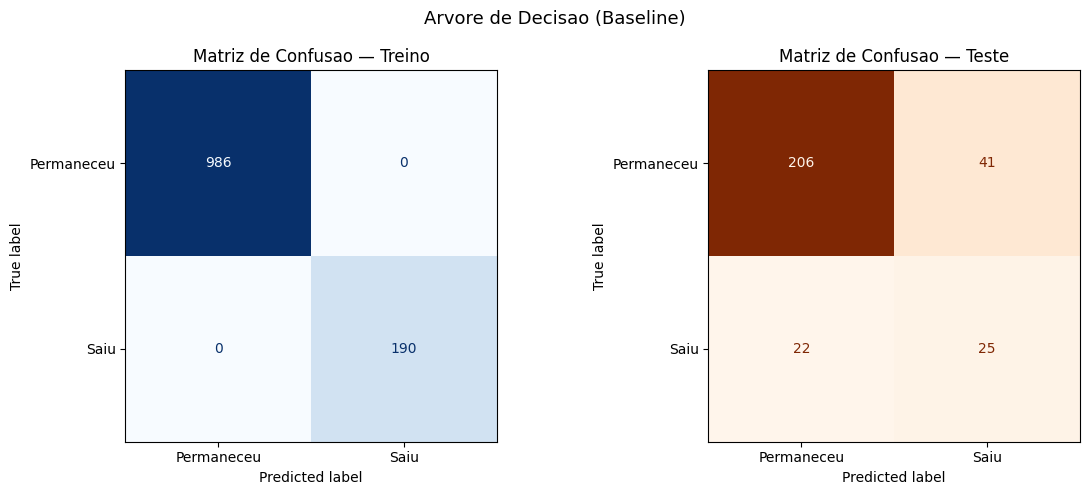

In [10]:
# 9. VISUALIZAÇÕES

# 9.1 Matrizes de Confusão — Treino e Teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_train, y_pred_train),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")

fig.suptitle("Arvore de Decisao (Baseline)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

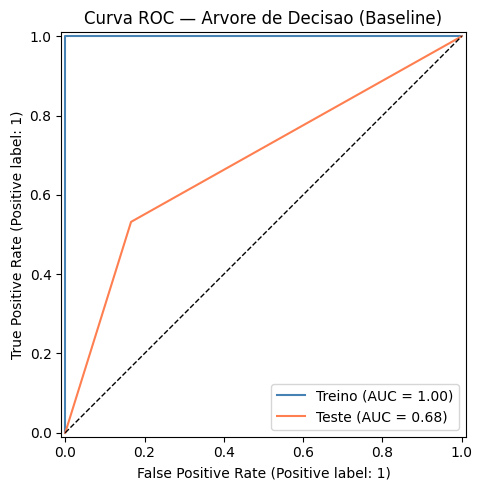

In [11]:
# 9.2 Curva ROC — Treino e Teste
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore de Decisao (Baseline)")
plt.tight_layout()
plt.savefig("roc_curve_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

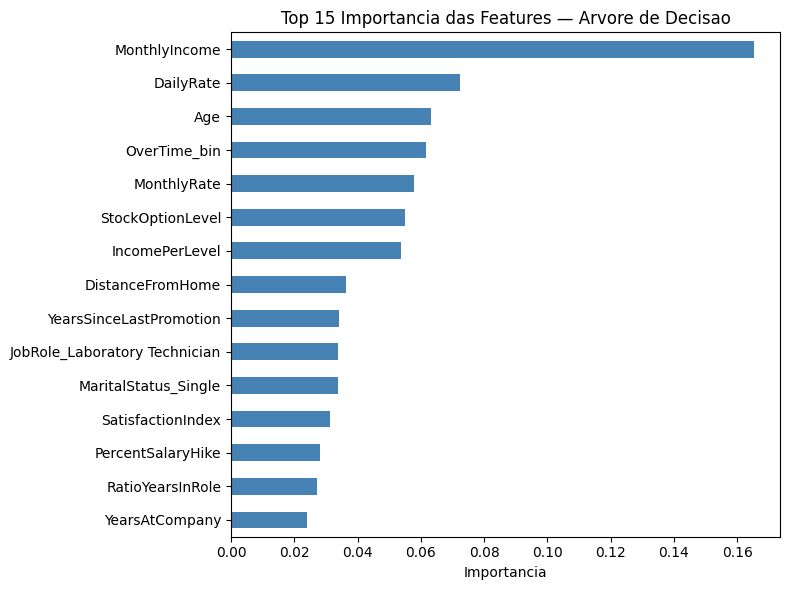

In [12]:
# 9.3 Top 15 Importância das Features
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore de Decisao")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

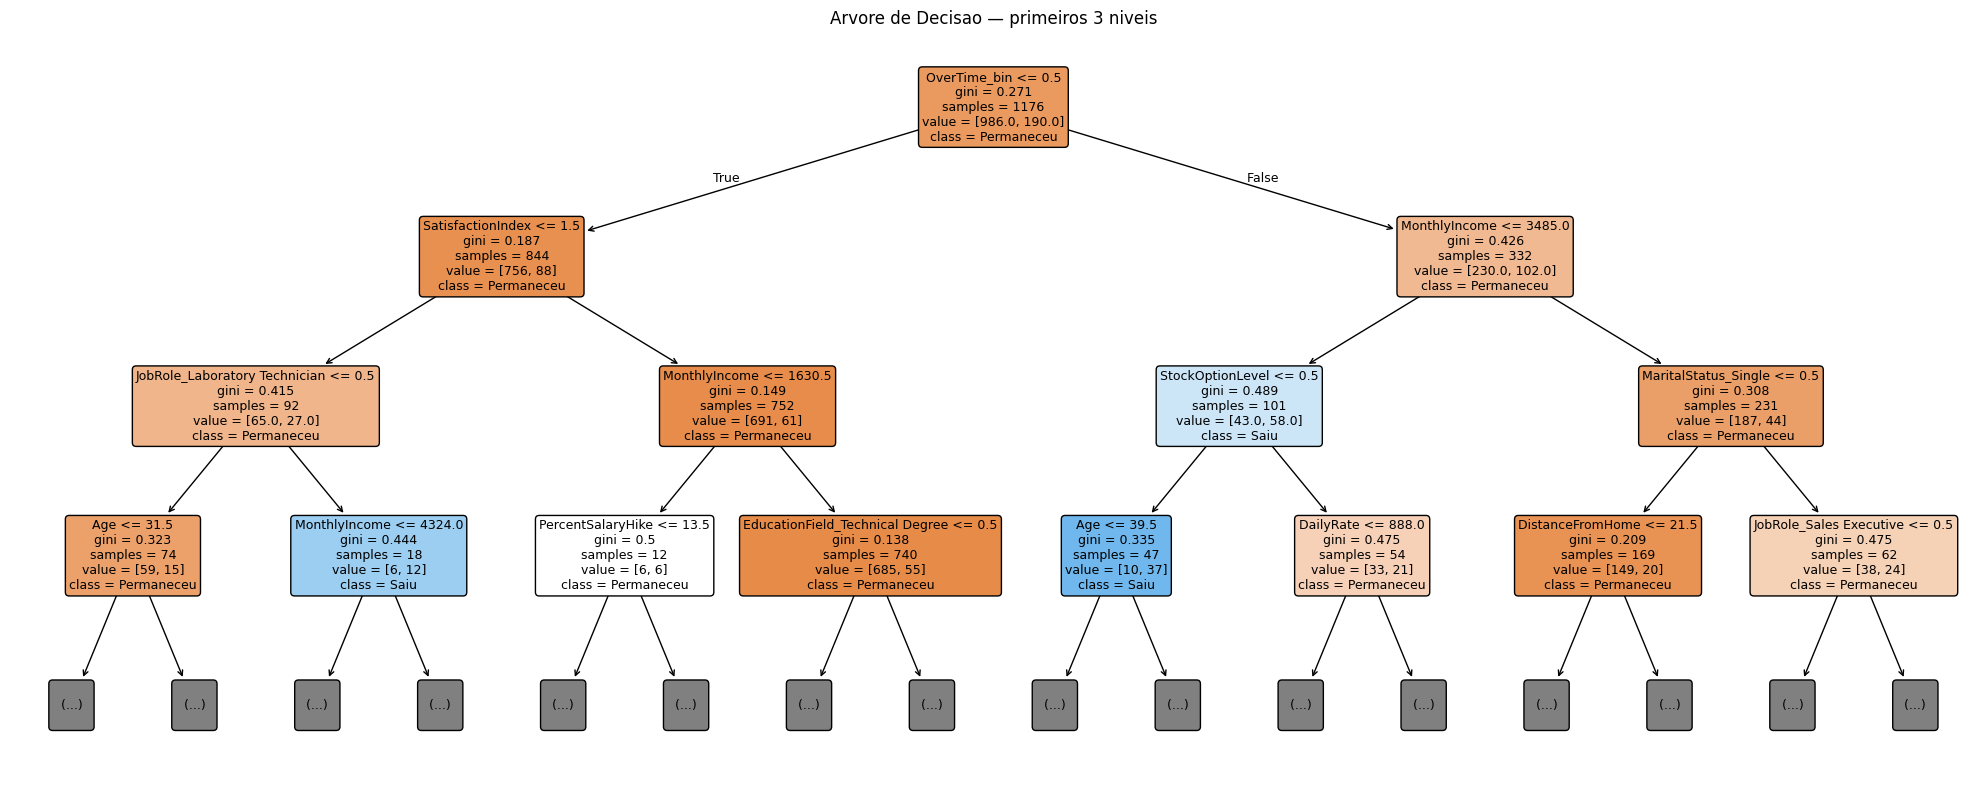

In [13]:
# 9.4 Visualização da Árvore (primeiros 3 níveis)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf, max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# 10. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 206  OK
  FP — Permaneceu, previsto Saiu:       41  Erro
  FN — Saiu, previsto Permaneceu:       22  Erro (critico)
  TP — Saiu, previsto Saiu:             25  OK

  O modelo falhou em detetar 22 saidas reais (Falsos Negativos).


In [15]:
# 11. RESUMO FINAL

print("=" * 55)
print("RESUMO — BASELINE")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao (parâmetros default)")
print(f"  Features:          {X.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (nao necessaria)")
print(f"  Balanceamento:     Nenhum (baseline simples)")
print(f"  Metrica principal: F1-Score")
print(f"  Profundidade:      {clf.get_depth()} niveis")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print()
print("  Referencial minimo para os modelos candidatos.")
print("=" * 55)

RESUMO — BASELINE
  Algoritmo:         Arvore de Decisao (parâmetros default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (nao necessaria)
  Balanceamento:     Nenhum (baseline simples)
  Metrica principal: F1-Score
  Profundidade:      17 niveis

  F1 treino: 1.0000
  F1 teste:  0.4425

  Referencial minimo para os modelos candidatos.
